2026-05-13 12:00:47,507 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 9.3e+00/s
2026-05-13 12:00:47,635 solvers 0/1 INFO :: Simulation stop time reached.


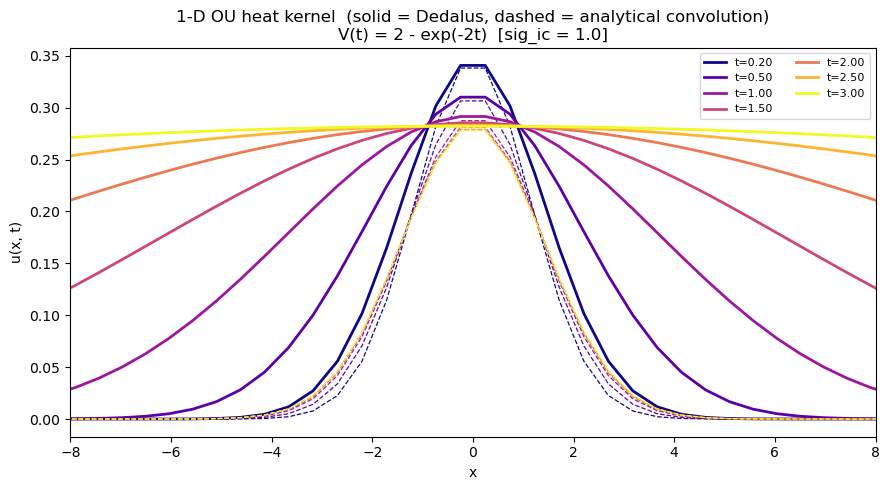

In [39]:
"""
1-D time-dependent Ornstein-Uhlenbeck IVP via Dedalus.

    du/dt = d²u/dx² - x du/dx  =  L u

Initial condition: Gaussian of width sig_ic centred at x0 = 0,
normalised to unit mass (approximating a delta function).

Exact Green's function (pure delta IC):
    K(x, t; x0=0) = [2π σ²(t)]^{-1/2}  exp( -x² / (2 σ²(t)) )
    σ²(t) = 1 - exp(-2t)

Because the IC has finite width sig_ic, the observed solution is the
convolution of K with the Gaussian IC:
    u(x, t) = [2π V(t)]^{-1/2}  exp( -x² / (2 V(t)) )
    V(t)    = σ²(t) + sig_ic²  =  1 - exp(-2t) + sig_ic²

For sig_ic = 1 this gives V(t) = 2 - exp(-2t).  SR discovers this form;
the true OU variance σ²(t) = V(t) - sig_ic² is recovered by subtracting
the known initial width.

SR features: r = |x - x0|,  t
"""

import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
import logging
logger = logging.getLogger(__name__)

# --- Domain ---
L = 20
N = 128
x_left, x_right = -L, L
dtype = np.float64

coords = d3.CartesianCoordinates('x')
dist   = d3.Distributor(coords, dtype=dtype)
xbasis = d3.Chebyshev(coords['x'], size=N, bounds=(x_left, x_right))

# --- Fields ---
u     = dist.Field(name='u',     bases=xbasis)
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')

# Coordinate field for the drift term  x · du/dx
xx = dist.Field(name='xx', bases=xbasis)
x_loc, = dist.local_grids(xbasis)
xx['g'] = x_loc

# --- Operator shorthands ---
lift_basis = xbasis.derivative_basis(2)
lift = lambda A, n: d3.Lift(A, lift_basis, n)
dx   = lambda A: d3.Differentiate(A, coords['x'])

# --- IVP:  dt u - lap u + x dx u = 0,  u(±L) = 0 ---
# Use an explicit namespace dict so no stale Jupyter globals (e.g. a float
# named 'dt' from a previous run) can shadow Dedalus's dt operator.
problem = d3.IVP(
    [u, tau_1, tau_2],
    namespace={
        'u': u, 'tau_1': tau_1, 'tau_2': tau_2,
        'lap': d3.lap, 'lift': lift, 'dx': dx,
        'xx': xx, 'x_left': x_left, 'x_right': x_right,
    }
)
problem.add_equation(
    "dt(u) - lap(u) + xx*dx(u) + lift(tau_1,-1) + lift(tau_2,-2) = 0"
)
problem.add_equation("u(x=x_left)  = 0")
problem.add_equation("u(x=x_right) = 0")

solver = problem.build_solver(d3.RK222)
solver.stop_sim_time = 3.0

# --- Initial condition: unit-mass Gaussian at x0 = 0 ---
x0     = 0.0
sig_ic = 1.0
u['g'] = np.exp(-(x_loc - x0)**2 / (2*sig_ic**2)) / (sig_ic * np.sqrt(2*np.pi))

# --- Time integration, saving snapshots ---
timestep = 0.01
t_plot   = np.array([0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
snaps    = {}

x_g = xbasis.global_grid(dist, scale=1).ravel()

while solver.proceed:
    solver.step(timestep)
    idx = len(snaps)
    if idx < len(t_plot) and solver.sim_time >= t_plot[idx] - timestep/2:
        snaps[solver.sim_time] = u.allgather_data('g').ravel().copy()

# --- Plot: numerical vs analytical convolution ---
if dist.comm.rank == 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    cmap  = plt.cm.plasma
    t_vals = sorted(snaps)
    for i, t in enumerate(t_vals):
        col = cmap(i / max(len(t_vals) - 1, 1))
        ax.plot(x_g, snaps[t], color=col, lw=2.0, label=f't={t:.2f}')
        # Analytical: convolution of IC Gaussian(0, sig_ic²) with K(·,t)
        V_t  = 1 - np.exp(-2*t) + sig_ic**2
        mu_t = x0 * np.exp(-t)
        K_eff = np.exp(-(x_g - mu_t)**2 / (2*V_t)) / np.sqrt(2*np.pi*V_t)
        ax.plot(x_g, K_eff, color=col, lw=0.9, ls='--')
    ax.set_xlim(-8, 8)
    ax.set_xlabel('x')
    ax.set_ylabel('u(x, t)')
    ax.set_title(
        '1-D OU heat kernel  (solid = Dedalus, dashed = analytical convolution)\n'
        f'V(t) = 2 - exp(-2t)  [sig_ic = {sig_ic}]'
    )
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig('ou_1d_ivp.png', dpi=200)
    plt.show()

In [ ]:
import numpy as np
import dedalus.public as d3

# --- Domain ---
L = 20
N = 128
x_left_ds, x_right_ds = -L, L
dtype = np.float64

coords_ds = d3.CartesianCoordinates('x')
dist_ds   = d3.Distributor(coords_ds, dtype=dtype)
xbasis_ds = d3.Chebyshev(coords_ds['x'], size=N, bounds=(x_left_ds, x_right_ds))

u_ds     = dist_ds.Field(name='u',     bases=xbasis_ds)
tau_1_ds = dist_ds.Field(name='tau_1')
tau_2_ds = dist_ds.Field(name='tau_2')

xx_ds = dist_ds.Field(name='xx', bases=xbasis_ds)
x_local_ds, = dist_ds.local_grids(xbasis_ds)
xx_ds['g'] = x_local_ds

lbds    = xbasis_ds.derivative_basis(2)
lift_ds = lambda A, n: d3.Lift(A, lbds, n)
dx_ds   = lambda A: d3.Differentiate(A, coords_ds['x'])

prob_ds = d3.IVP(
    [u_ds, tau_1_ds, tau_2_ds],
    namespace={
        'u': u_ds, 'tau_1': tau_1_ds, 'tau_2': tau_2_ds,
        'lap': d3.lap, 'lift': lift_ds, 'dx': dx_ds,
        'xx': xx_ds, 'x_left': x_left_ds, 'x_right': x_right_ds,
    }
)
prob_ds.add_equation(
    "dt(u) - lap(u) + xx*dx(u) + lift(tau_1,-1) + lift(tau_2,-2) = 0"
)
prob_ds.add_equation("u(x=x_left)  = 0")
prob_ds.add_equation("u(x=x_right) = 0")

solver_ds = prob_ds.build_solver(d3.RK222)
solver_ds.stop_sim_time = 6.0

# --- IC ---
x0_ds     = 0.0
sig_ic_ds = 1.0
u_ds['g'] = (
    np.exp(-(x_local_ds - x0_ds)**2 / (2*sig_ic_ds**2))
    / (sig_ic_ds * np.sqrt(2*np.pi))
)

# --- Snapshot times: log-spaced from t=0.01 to t=6.
# Starting at t=0.01 (not 0.1) is key for distinguishing exp(-2t) from t^n:
# at t=0.01, V(t)=1.02 while any power law that fits the t~1 region
# predicts V~2, a clear mismatch that rules out the power-law hypothesis.
timestep_ds = 0.002   # small enough to hit the earliest targets near t=0.01
t_snaps = np.logspace(np.log10(0.01), np.log10(6.0), 600)
r_min   = 2.0
r_max   = 7.0

x_g_ds = xbasis_ds.global_grid(dist_ds, scale=1).ravel()

r_list, t_list, u_list = [], [], []
snap_idx = 0

while solver_ds.proceed and snap_idx < len(t_snaps):
    solver_ds.step(timestep_ds)
    t_now = solver_ds.sim_time
    if t_now >= t_snaps[snap_idx] - timestep_ds / 2:
        ug   = u_ds.allgather_data('g').ravel()
        r_f  = np.abs(x_g_ds - x0_ds)
        mask = (r_f > r_min) & (r_f < r_max)
        r_list.append(r_f[mask])
        t_list.append(np.full(mask.sum(), t_now))
        u_list.append(ug[mask])
        snap_idx += 1

r_arr = np.concatenate(r_list)
t_arr = np.concatenate(t_list)
u_arr = np.concatenate(u_list)

np.save('ou_1d_ivp_train.npy', np.column_stack([r_arr, t_arr, u_arr]))
print(f"Dataset: {len(r_arr):,} points across {snap_idx} snapshots")
print(f"r  in [{r_arr.min():.3f}, {r_arr.max():.3f}]")
print(f"t  in [{t_arr.min():.4f}, {t_arr.max():.3f}]")
print(f"u  in [{u_arr.min():.4e}, {u_arr.max():.4e}]")

In [41]:
from pysr import PySRRegressor

In [ ]:
data  = np.load('ou_1d_ivp_train.npy')
r_sr  = data[:, 0]
t_sr  = data[:, 1]
u_sr  = data[:, 2]

# Filter out very small values before taking log
pos   = u_sr > 1e-6
r_sr, t_sr, u_sr = r_sr[pos], t_sr[pos], u_sr[pos]
log_u = np.log(u_sr)

X_sr = np.stack([r_sr, t_sr], axis=1)

print(f"Total usable points: {len(log_u):,}")

# Subsample
rng_sr = np.random.default_rng(seed=42)
idx    = rng_sr.choice(len(log_u), size=min(10000, len(log_u)), replace=False)
X_sub, y_sub = X_sr[idx], log_u[idx]

print(f"Training SR on: {len(y_sub):,} points")

model = PySRRegressor(
    niterations=50,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=["exp", "log", "sqrt", "inv"],
    complexity_of_operators={"^": 2, "/": 2, "exp": 3, "log": 3, "sqrt": 2},
    maxsize=25,
    delete_tempfiles=True,
    variable_names=["r", "t"],
)

/opt/miniconda3/envs/dedalus3/lib/python3.14/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(


Total usable points: 13,146
Training SR on: 13,146 points


In [ ]:
import pandas as pd

model.fit(X_sub, y_sub)


In [55]:

# Show the full Pareto front without pandas truncating long strings
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
print(model.equations_[['complexity', 'loss', 'equation']].to_string(index=False))

# Best equation — highest score on the Pareto front
print('\n--- Best equation ---')
best = model.get_best()
print('Complexity:', best['complexity'])
print('Loss      :', best['loss'])
print('String    :', best['equation'])
print('SymPy     :', model.sympy())
print('LaTeX     :', model.latex())

 complexity     loss                                                                                  equation
          1 7.512588                                                                                 -3.626148
          3 4.141972                                                                                   x1 - x0
          5 4.090835                                                                   x1 - (x0 - -0.22630894)
          6 0.975104                                                                    x0 / (-0.5066985 - x1)
          8 0.365897                                                      (1.5280241 - x0) / (x1 + 0.26462254)
          9 0.159118                                                        (x0 * -0.5932073) / (x1 + inv(x0))
         11 0.147004                                       ((x0 * -0.57489187) / (x1 + inv(x0))) + -0.17795621
         12 0.138815                                           -0.57489187 * (inv(x0) + (x0 / (x1 + inv(x0))))
 

In [58]:
print(best)

complexity                                                                                                 20
loss                                                                                                 0.009028
equation            ((0.8352729 - x0) / (((inv(x0) * 4.553398) + x1) * (exp(x1) + -0.62491125))) + -1.1853399
score                                                                                                0.657991
sympy_format                      -1.1853399 + (0.8352729 - x0)/(((x1 + 4.553398/x0)*(exp(x1) - 0.62491125)))
lambda_format    PySRFunction(X=>-1.1853399 + (0.8352729 - x0)/(((x1 + 4.553398/x0)*(exp(x1) - 0.62491125))))
Name: 13, dtype: object
